# Model and Evaluation for Approval Predict 

## Objective:

* Answer business requirement 2:
The client aims to offer a guide for potential applicants by identifying the influential factors that contribute to loan approval. These insights will be used to recommend specific improvements for applicants and guide them to increase their chances of having a loan approved.

* Fit and evaluate classification models to predict loan approval outcomes. Classification will directly predict whether a loan is approved.

## Inputs
* outputs/datasets/collection/loan_approved.csv
* Instructions on which variables to use for data cleaning and feature engineering. They are found in each respective notebook.

## Outputs
* Train set (features and target)
* Test set (features and target)
* Data cleaning and Feature Engineering pipeline
* Modeling pipeline
* Feature importance plot

## Change Working Directory

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

current_dir = os.getcwd()
current_dir

'/workspaces/Approval_Predict/jupyter_notebooks'

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


In [3]:
current_dir = os.getcwd()
current_dir

'/workspaces/Approval_Predict'

## Load data

In [4]:
root = current_dir
file_path = Path(root) / "outputs" / "datasets" / "collection" / "loan_approval.csv"

if not file_path.exists():
    raise FileNotFoundError(f"Dataset not found at: {file_path}")

df = pd.read_csv(file_path).drop(['name', 'city'], axis=1)
df.head(3)

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389,39698,27,50.0,False
1,44592,729,15446,28,55.0,False
2,33278,584,11189,13,45.0,False


## ML Pipeline with all data
ML pipeline for Data Cleaning and Feature Engineering

In [5]:
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from feature_engine.transformation import YeoJohnsonTransformer, BoxCoxTransformer

final_features = ['points', 'loan_to_income']

def approval_pipeline():
    """
    Create a machine learning pipeline that applies Yeo-Johnson and Box-Cox
    transformations, robust scaling, and a classification model for predicting
    loan approval.
    """
    
    pipeline = Pipeline([
        ('yeojohnson', YeoJohnsonTransformer(variables=['points'])),
        ('boxcox', BoxCoxTransformer(variables=['loan_to_income'])),
        ('scaler', RobustScaler()),
        ('model', LogisticRegression)
    ])
    
    return pipeline


## ML Pipeline for Modelling and Hyperparameter Optimisation

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

def PipelineClf(model):
    """
    Builds a pipeline for hyperparameter optimisation that includes
    feature transformations, robust scaling and a classifier model.
    """
    return Pipeline([
        ("yeojohnson", YeoJohnsonTransformer(variables=['points'])),
        ("boxcox", BoxCoxTransformer(variables=['loan_to_income'])),
        ("scaler", RobustScaler()),
        ("model", model),
    ])

Custom Class for Hyperparameter Optimisation (code institute)

In [7]:
from sklearn.model_selection import GridSearchCV


class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")

            model = PipelineClf(self.models[key])
            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs,
                              verbose=verbose, scoring=scoring, )
            gs.fit(X, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
            }
            return pd.Series({**params, **d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]
                scores.append(r.reshape(len(params), 1))

            all_scores = np.hstack(scores)
            for p, s in zip(params, all_scores):
                rows.append((row(k, s, p)))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)
        columns = ['estimator', 'min_score',
                   'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]
        return df[columns], self.grid_searches

## Split Train and Test Set

In [12]:
from sklearn.model_selection import train_test_split

df['loan_to_income'] = df['loan_amount'] / df['income']

final_features = ['points', 'loan_to_income']
X = df[final_features].copy()

y = df['loan_approved'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Train/Test Split Shapes:")
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

Train/Test Split Shapes:
(1600, 2) (1600,) (400, 2) (400,)


## Handle Target Imbalance

Check Train Set Target distribution

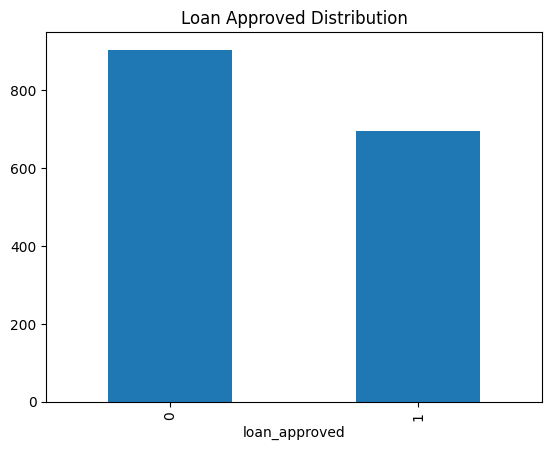

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

y_train.value_counts().plot(kind='bar', title='Loan Approved Distribution')
plt.show()

Use SMOTE (Synthetic Minority Oversampling TEchnique) to balance Train Set target

After SMOTE: (1808, 2) (1808,)


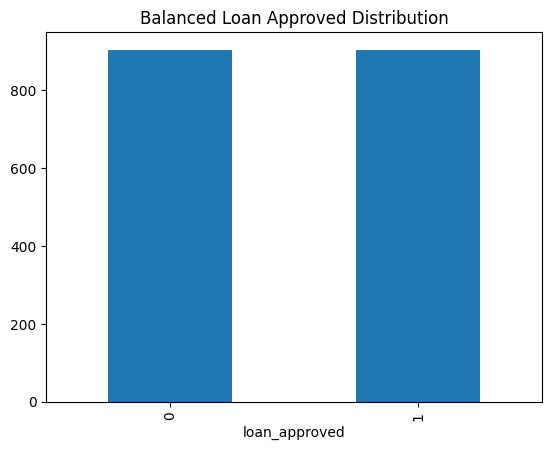

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority', random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train_bal.shape, y_train_bal.shape)

y_train_bal.value_counts().plot(kind='bar', title='Balanced Loan Approved Distribution')
plt.show()

## Grid Search CV - Sklearn

Use standard hyperparameters to find most suitable algorithm

In [8]:
models_quick_search = {
    "LogisticRegression": LogisticRegression(random_state=42),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "ExtraTreesClassifier": ExtraTreesClassifier(random_state=42),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(random_state=42)
}

params_quick_search = {
    "LogisticRegression": {},
    "DecisionTreeClassifier": {},
    "RandomForestClassifier": {},
    "GradientBoostingClassifier": {},
    "ExtraTreesClassifier": {},
    "AdaBoostClassifier": {},
    "XGBClassifier": {},
}


Quick GridSearch CV - Binary Classifier

In [20]:
from sklearn.metrics import recall_score, make_scorer

search = HyperparameterOptimizationSearch(
    models=models_quick_search,
    params=params_quick_search
)

search.fit(
    X_train_bal,
    y_train_bal,
    scoring=make_scorer(recall_score, pos_label=1),
    cv=5,
    n_jobs=-1,
    verbose=1
)


Running GridSearchCV for LogisticRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for DecisionTreeClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for RandomForestClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for AdaBoostClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for XGBClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_spars

In [21]:
results_summary, search_pipelines = search.score_summary(sort_by='mean_score')
results_summary

,estimator,min_score,mean_score,max_score,std_score
0,LogisticRegression,1.0,1.0,1.0,0.0
1,DecisionTreeClassifier,1.0,1.0,1.0,0.0
2,RandomForestClassifier,1.0,1.0,1.0,0.0
3,GradientBoostingClassifier,1.0,1.0,1.0,0.0
4,ExtraTreesClassifier,1.0,1.0,1.0,0.0
5,AdaBoostClassifier,1.0,1.0,1.0,0.0
6,XGBClassifier,1.0,1.0,1.0,0.0


##  complete previous phase with additional features

In [22]:
additional_features_added = [
    'points',
    'loan_to_income',
    'credit_score',
    'years_employed',
    'loan_amount'
]

In [23]:
X = df[additional_features_added].copy()
y = df['loan_approved'].astype(int)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [25]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [26]:
pipeline = Pipeline([
    ('yeojohnson', YeoJohnsonTransformer(variables=['points'])),
    ('boxcox', BoxCoxTransformer(variables=['loan_to_income'])),
    ('scaler', RobustScaler()),
    ('model', LogisticRegression)
])

In [28]:
results_summary, search_pipelines = search.score_summary(sort_by='mean_score')
results_summary


,estimator,min_score,mean_score,max_score,std_score
0,LogisticRegression,1.0,1.0,1.0,0.0
1,DecisionTreeClassifier,1.0,1.0,1.0,0.0
2,RandomForestClassifier,1.0,1.0,1.0,0.0
3,GradientBoostingClassifier,1.0,1.0,1.0,0.0
4,ExtraTreesClassifier,1.0,1.0,1.0,0.0
5,AdaBoostClassifier,1.0,1.0,1.0,0.0
6,XGBClassifier,1.0,1.0,1.0,0.0
